In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visualization 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Locate processed data
resumes_path = Path("data/processed/resumes_clean.csv")
if not resumes_path.exists():
    resumes_path = Path("../data/processed/resumes_clean.csv")

jobs_path = Path("data/processed/jobs_clean.csv")
if not jobs_path.exists():
    jobs_path = Path("../data/processed/jobs_clean.csv")

resumes = pd.read_csv(resumes_path)
jobs = pd.read_csv(jobs_path)

print(f"Resumes: {resumes.shape[0]} rows, {resumes.shape[1]} columns")
print(f"Jobs:    {jobs.shape[0]} rows, {jobs.shape[1]} columns")

Resumes: 962 rows, 3 columns
Jobs:    20000 rows, 35 columns


Category summary:
count    25.000000
mean     38.480000
std      14.574864
min      20.000000
25%      28.000000
50%      40.000000
75%      42.000000
max      84.000000
Name: count, dtype: float64


/tmp/ipykernel_22966/3898282904.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.index, x=category_counts.values, palette="mako")


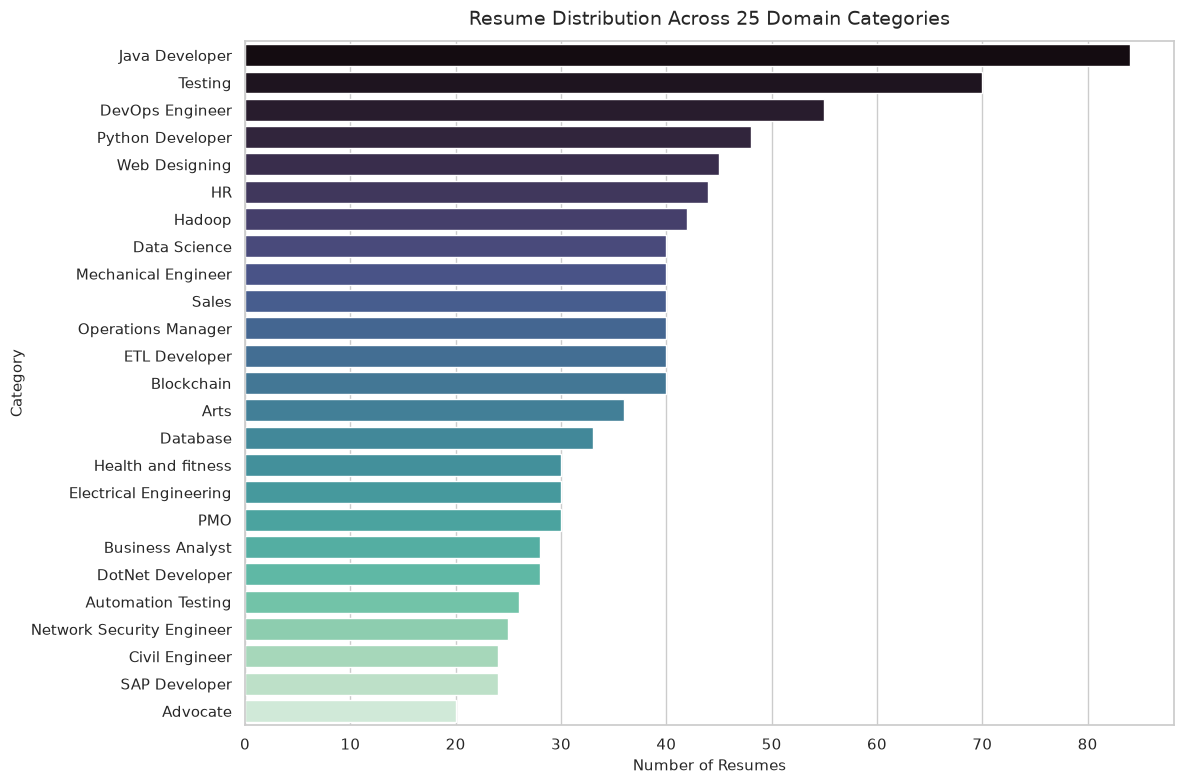

In [3]:
category_counts = resumes['Category'].value_counts()
print("Category summary:")
print(category_counts.describe())

plt.figure(figsize=(12, 8))
sns.barplot(y=category_counts.index, x=category_counts.values, palette="mako")
plt.title("Resume Distribution Across 25 Domain Categories", fontsize=14, pad=12)
plt.xlabel("Number of Resumes", fontsize=11)
plt.ylabel("Category", fontsize=11)
plt.tight_layout()
plt.show()

Resume Word Count Summary:
count     962.000000
mean      427.167360
std       392.655179
min        16.000000
25%       159.000000
50%       308.000000
75%       559.000000
max      2054.000000
Name: word_count, dtype: float64


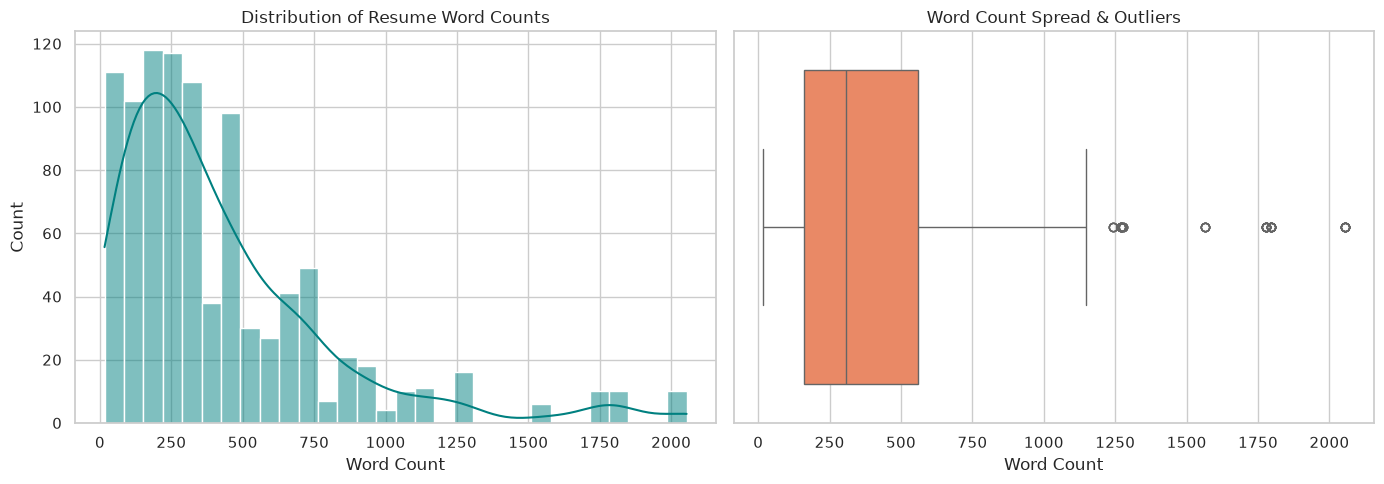

In [ ]:
# Text metrics on raw vs cleaned text
resumes['char_count'] = resumes['Resume_Clean'].fillna('').apply(len)
resumes['word_count'] = resumes['Resume_Clean'].fillna('').apply(lambda x: len(x.split()))

print("Resume Word Count Summary:")
print(resumes['word_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(resumes['word_count'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title("Distribution of Resume Word Counts")
axes[0].set_xlabel("Word Count")

sns.boxplot(x='word_count', data=resumes, ax=axes[1], color='coral')
axes[1].set_title("Word Count Spread & Outliers")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Discriminative keywords for a chosen category
sample_cat = "Data Science"
sample_docs = resumes[resumes['Category'] == sample_cat]['Resume_Clean'].dropna()

vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
X_cat = vectorizer.fit_transform(sample_docs)
top_words = pd.Series(X_cat.toarray().mean(axis=0), index=vectorizer.get_feature_names_out()).sort_values(ascending=False)

print(f"Top TF-IDF keywords for {sample_cat}:")
print(top_words.head(10))

Top TF-IDF keywords for Data Science:
data         0.340880
exprience    0.296396
months       0.280576
year         0.250756
learning     0.187593
science      0.179137
python       0.172742
details      0.159154
machine      0.147116
analysis     0.118412
dtype: float64


Job Posting Missing Value Percentages:
title                          0.00
company                       85.70
location                       0.34
skills                        86.08
description                    0.00
experience                    85.70
job_id                        14.30
company_name                  15.40
max_salary                    79.12
pay_period                    74.75
company_id                    15.40
views                         15.56
med_salary                    95.63
min_salary                    79.12
formatted_work_type           14.30
applies                       83.74
original_listed_time          14.30
remote_allowed                89.62
job_posting_url               14.30
application_url               39.36
application_type              14.30
expiry                        14.30
closed_time                   99.34
formatted_experience_level    34.18
skills_desc                   98.47
listed_time                   14.30
posting_domain           

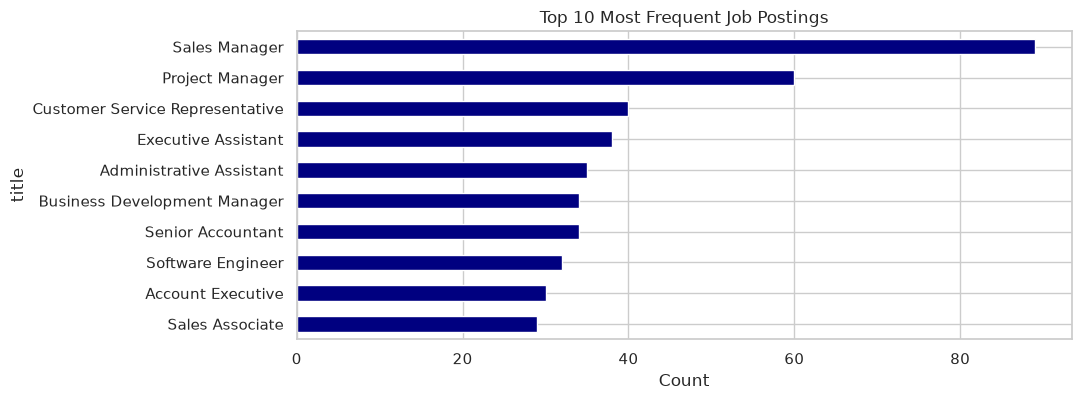

/tmp/ipykernel_22966/1819404306.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_skills.index, x=top_skills.values, palette="viridis")


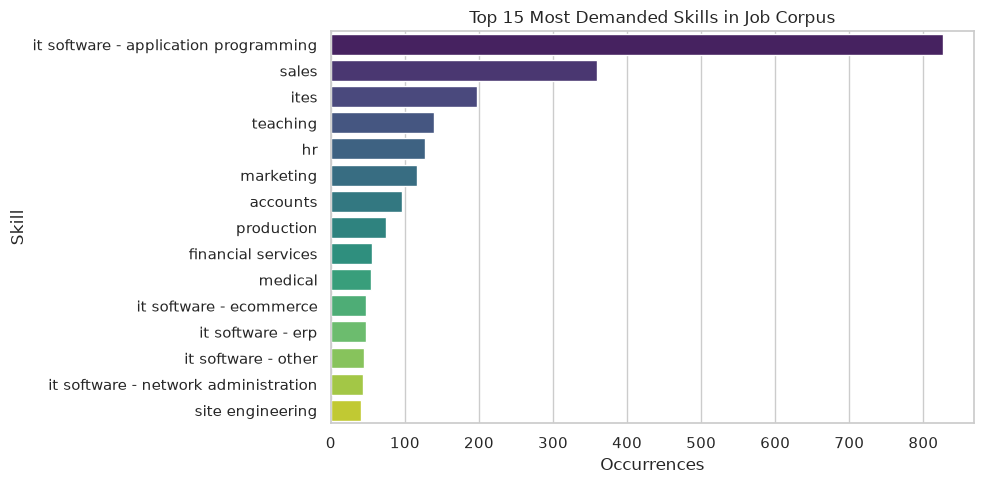

In [ ]:
# Missing values in job posting 
print("Job Posting Missing Value Percentages:")
print((jobs.isnull().sum() / len(jobs) * 100).round(2))


plt.figure(figsize=(10, 4))
jobs['title'].value_counts().head(10).plot(kind='barh', color='navy').invert_yaxis()
plt.title("Top 10 Most Frequent Job Postings")
plt.xlabel("Count")
plt.show()

# Top recurring skills
skill_series = jobs['skills'].dropna().str.split(',').explode().str.strip().str.lower()
top_skills = skill_series[skill_series != ''].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(y=top_skills.index, x=top_skills.values, palette="viridis")
plt.title("Top 15 Most Demanded Skills in Job Corpus")
plt.xlabel("Occurrences")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()